# Week 2 Notes

## 2.1 [Car price prediction project](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/01-car-price-intro.md)

This week walk through a car price prediction project. User wants to sell a car, but doesn't know for how much. A regression model will be developed to recommend a car price. Dataset will be Cars dataset from Kaggle.

1. Prepare data and do Exploratory Data Analysis (EDA)
1. Use linear regression for predicting price
1. Understand linear regression internals (implement ourselves)
1. Evaluate quality of the model using RMSE
1. Feature Engineering (create new characteristics for our model to use)
1. Regularization (make model numerically stable)
1. Use the model

## 2.2 [Data Preparation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/02-data-preparation.md)

In [180]:
import pandas as pd
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df = pd.read_csv(data)

Let's do some data cleaning. First, let's make column spaces consistent with lower caps and underscores as separators.

In [181]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

The colum names have been standardized. Let's now take care of the values:

The string columns are of type object. Let's select those. Also we will convert those to `str`, since that will take up less memory.

In [182]:
object_columns_list = df.select_dtypes(object).columns

df[object_columns_list] = (
    df.select_dtypes(object)
    .apply(lambda x: (
        x
        .str.lower()
        .str.replace(" ", "_")
    ) 
    , axis='index')
)

In [183]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


## 2.3 [Exploratory data analysis](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/03-eda.md)

Check 5 unique values per column (first with `.apply()`, then with for-loop):

In [184]:
df.apply(lambda x: print(x.name, "\n", x.unique()[:5], "\n"), axis="index");

make 
 ['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler'] 

model 
 ['1_series_m' '1_series' '100' '124_spider' '190-class'] 

year 
 [2011 2012 2013 1992 1993] 

engine_fuel_type 
 ['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel'] 

engine_hp 
 [335. 300. 230. 320. 172.] 

engine_cylinders 
 [ 6.  4.  5.  8. 12.] 

transmission_type 
 ['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown'] 

driven_wheels 
 ['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive'] 

number_of_doors 
 [ 2.  4.  3. nan] 

market_category 
 ['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance'] 

vehicle_size 
 ['compact' 'midsize' 'large'] 

vehicle_style 
 ['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback'] 

highway_mpg 
 [26 28 27 25 24] 

city_mpg 
 [19 20 18 17 16] 

popularity 
 [3916 3105  819  617 1013] 

msrp 
 [46135 40650 36350 2945

In [185]:
for col in df.columns:
    print(col, "\n", df[col].unique()[:5], "\n")

make 
 ['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler'] 

model 
 ['1_series_m' '1_series' '100' '124_spider' '190-class'] 

year 
 [2011 2012 2013 1992 1993] 

engine_fuel_type 
 ['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel'] 

engine_hp 
 [335. 300. 230. 320. 172.] 

engine_cylinders 
 [ 6.  4.  5.  8. 12.] 

transmission_type 
 ['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown'] 

driven_wheels 
 ['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive'] 

number_of_doors 
 [ 2.  4.  3. nan] 

market_category 
 ['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance'] 

vehicle_size 
 ['compact' 'midsize' 'large'] 

vehicle_style 
 ['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback'] 

highway_mpg 
 [26 28 27 25 24] 

city_mpg 
 [19 20 18 17 16] 

popularity 
 [3916 3105  819  617 1013] 

msrp 
 [46135 40650 36350 2945

Show number of unique values per column:

In [186]:
df.nunique()

make                   48
model                 914
year                   28
engine_fuel_type       10
engine_hp             356
engine_cylinders        9
transmission_type       5
driven_wheels           4
number_of_doors         3
market_category        71
vehicle_size            3
vehicle_style          16
highway_mpg            59
city_mpg               69
popularity             48
msrp                 6049
dtype: int64

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

Let's plot a histogram:

<Axes: xlabel='msrp', ylabel='Count'>

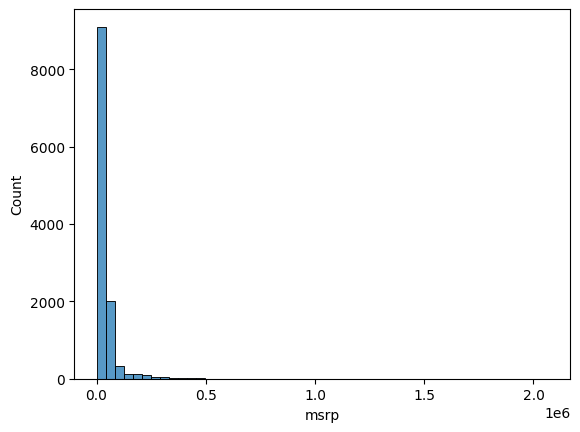

In [188]:
sns.histplot(df.msrp, bins=50)

This is called a 'long-tail distribution', where there are some outliers. To deal with this, we can provide a cut-off price. Let's cut it off at 100,000:

<Axes: xlabel='msrp', ylabel='Count'>

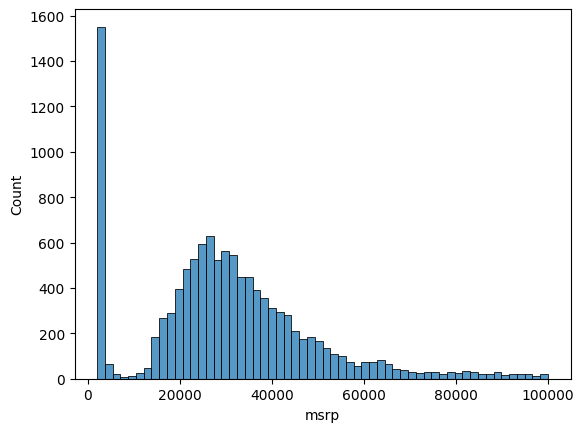

In [189]:
sns.histplot(df.msrp[df.msrp < 100_000])

The peak on the left is likely to be the minimum price:

In [190]:
df.msrp.sort_values()

775         2000
767         2000
768         2000
769         2000
770         2000
          ...   
6351     1382750
8486     1500000
11363    1500000
11364    1705769
11362    2065902
Name: msrp, Length: 11914, dtype: int64

In [191]:
(df.msrp==2000).sum()

np.int64(1036)

A long-tail distribution is not good for Machine Learning models, it will confuse them. We can deal with this by a logarithmic transformation of the data.

In [192]:
import numpy as np


x = [0, 1, 10, 100, 1_000, 10_000, 100_000]
y = np.log1p(x)

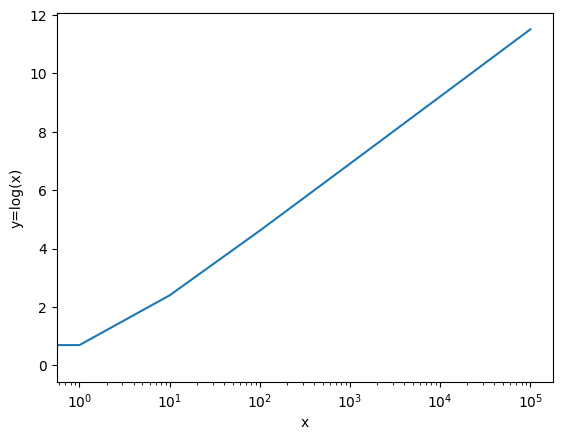

In [193]:
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y=log(x)")
plt.xscale("log")

The log transformation ensures that even for very large values of x, y does not explode in magnitude.

In [194]:
np.log1p(df.msrp)

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

Text(0.5, 1.0, 'With log transform')

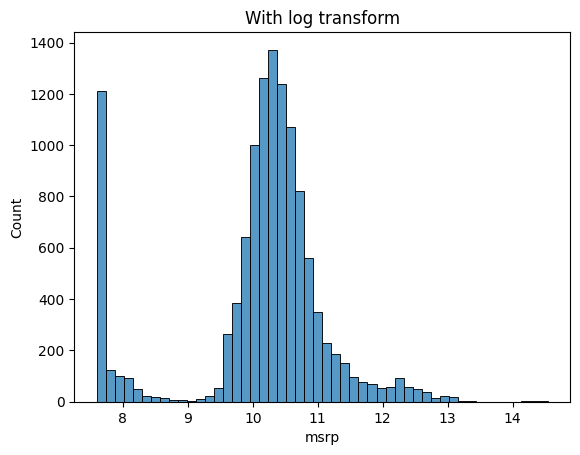

In [195]:
sns.histplot(np.log1p(df.msrp), bins=50).set_title("With log transform")

Text(0.5, 1.0, 'Without log transform')

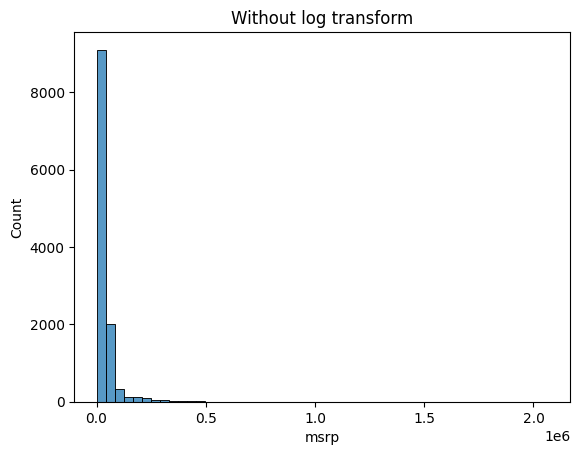

In [196]:
sns.histplot(df.msrp, bins=50).set_title("Without log transform")

We can see that with the log transformation, the price columnn `df.msrp` now looks like more like a normal distribution than a long-tail distribution. This way we don't need to discard data and our ML model will be able to use this column.

Let's now check missing values

In [197]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 [Setting up the validation framework](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/04-validation-framework.md)

We will discuss the data into: Train, Validation, Test. Test will only be evaluated at the very end.
- Train: $\mathbf{X}_T, \mathbf{y}_T$
- Validation: $\mathbf{X}_V, \mathbf{y}_V$
- Test: $\mathbf{X}_{TEST}, \mathbf{y}_{TEST}$

We'll split the data using Pandas into 60% training, 20% validation, 20% test. 20% of the dataset amounts to (rounded to nearest integer):

In [198]:
n = len(df)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test

In [199]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [200]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

The problem is that the data is organized. So looking at validation set for instance, we see that it starts off with the BMW's:

In [201]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37380
9528,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,extended_cab_pickup,23,16,1385,40100
9529,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42560
9530,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42860


Then looking at the train set, we see it starts with all fords:

In [202]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7146,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7147,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65055
7148,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,67220


This is a problem, because our datasets for training, validation, testing should be distributed similarly. To address this, we can shuffle the data.

In [203]:
idx = np.arange(n)

In [204]:
np.random.seed(2)
np.random.shuffle(idx)

In [205]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [206]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [207]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [208]:
X_train = df_train.drop(columns='msrp').values
X_val = df_val.drop(columns='msrp').values
X_test = df_test.drop(columns='msrp').values

## 2.5 [Linear regression](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/05-linear-regression-simple.md)

Linear regression is a model to predict a continuous variable. Let's take our ML model:

$$
g(\mathbf{X}) \approx \mathbf{y}
$$

For now, let's look at a single observation:

$$
g(\mathbf{x}_i) \approx y_i
$$

The vector $\mathbf{x}_i$ is:

$$
\mathbf{x}_i = \begin{bmatrix} x_{i1} & x_{i2} & \dotsb & x_{iN} \end{bmatrix}
$$

and the corresponding $y_i$:

$$
y_i = g(\begin{bmatrix} x_{i1} & x_{i2} & \dotsb & x_{iN} \end{bmatrix})
$$


Now, let's look at a given row of our data:

In [209]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
msrp                                      479775
Name: 10, dtype: object

We will handpick some columns: `engine_hp`, `city_mpg`, `popularity`:

$$
x_i = \begin{bmatrix} 147 & 17 & 586 \end{bmatrix}
$$

Let's now find a model $g$ that takes in $x_i$ and predicts the price $y_i$. In linear regression, our model looks as follows:

$$
g(\mathbf{x_i}) = w_o + w_1 \cdot x_1 + w_2 \cdot x_2 + w_3 \cdot x_3 = w_0 + \sum_{i=1}^3 w_i x_i
$$

Now, let's implement linear regression in code:


In [210]:
w0 = 0
w = [1, 1, 1]

def linear_regression(xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + w[j]*xi[j]
    return pred

In [211]:
xi = [147, 16, 586]

linear_regression(xi)

749

The values for w0 and w are randomly chosen, therefore the prediction does not make much sense. Let's try different values:

In [212]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

linear_regression(xi)

10.452000000000002

How can we interpret the model and prediction we came up with?

$$
0.01 \cdot 147 + 0.04 \cdot 16 + 0.002 \cdot 586 = 10.45
$$

The first term corresponds to `engine_hp`. The weight of $0.01$ means that each unit increase in engine horsepower results in a (log) price increase of 1.47. The weight therefore is a factor which indicates the importance of a given feature. If the weight is very high, that feature has a strong influence on the price.

First, note that what we predict is the logarithm of the price, not the price itself. To undo the logarithm transform, we can use the formula:

In [213]:
np.expm1(10.45)

np.float64(34543.37470927775)

## 2.6 [Linear regression: vector form](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/06-linear-regression-vector.md)

We can write the linear regression equation in vector form:

$$
g(\mathbf{x_i}) = \begin{bmatrix} 1 & x_{i1} & x_{i2} & x_{i3} \end{bmatrix} \begin{bmatrix} w_0 \\ w_1 \\ w_2 \\ w_3 \end{bmatrix} = \langle \mathbf{x}_i, \mathbf{w}_i \rangle = \mathbf{x}_i^T \mathbf{w}_i
$$

In [214]:
xi = [1] + xi
w = np.array([w0] + w)

def linear_regression(xi, w):
    return np.dot(xi, w)

In [215]:
linear_regression(xi, w)

np.float64(10.452000000000002)

Now let's go back to all observations, not just one.

$$
\mathbf{X} \mathbf{w} =

\begin{bmatrix} 1 & x_{11} & x_{12} & \dots & n_{1n} 
             \\ 1 & x_{21} & x_{22} & \dots & x_{2n} \\ 
             \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 
             \\ 1 & x_{m1} & x_{m2} & \dots & x_{mn} \\ 
\end{bmatrix}

\begin{bmatrix}
w_0 \\ w_1 \\ \vdots \\ w_m
\end{bmatrix} = 

\begin{bmatrix}
\mathbf{x}_1^T \mathbf{w} \\ \mathbf{x}_2^T \mathbf{w} \\ \vdots \\ \mathbf{x}_m^T \mathbf{w}
\end{bmatrix} 

$$

In [216]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [217]:
X_train = df_train[["engine_hp", "city_mpg", "popularity"]].values

def linear_regression(X_train, w):
    X_train = np.hstack([np.ones(shape=(X_train.shape[0], 1)), X_train])
    return X_train @ w

In [218]:
linear_regression(X_train, w)

array([12.38 , 13.552, 11.05 , ..., 11.798, 13.492, 11.796])

## 2.7 [Training linear regression: Normal equation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/07linear-regression-training.md)

In the previous lesson, we built a function to make predictions using weights and a feature matrix. But how do we find these weights?

Ideally, we want our model $g(\mathbf{X})$ to match $y$, but since that is usually not possible, we try to approximate it instead. 

$$
g(\mathbf{X}) \approx y
$$

Our model is defined as:

$$
g(\mathbf{X}) = \mathbf{X} \mathbf{w}
$$

This gives the equation:

$$
\mathbf{y} \approx \mathbf{X} \mathbf{w}
$$

If $\mathbf{X}$ were invertible, we could solve for $\mathbf{w}$ by left-multiplying by $\mathbf{X}^{-1}$:

$$
\mathbf{w} \approx \mathbf{X}^{-1} \mathbf{y}
$$

However, $\mathbf{X}$ is typically not square and thus not invertible. To address this, we left-multiply by the transpose $\mathbf{X^T}$:

$$
\mathbf{X}^T \mathbf{X} \mathbf{w} \approx \mathbf{X}^T \mathbf{y}
$$

This forms the Gram Matrix $\mathbf{X}^T \mathbf{X}$, which is usually invertible.

$$
\underbrace{\mathbf{X}^T \mathbf{X}}_{\text{Gram Matrix}} \mathbf{w} \approx \mathbf{X}^T \mathbf{y}
$$

Since the  Gram matrix  does have an inverse, we can left-multiply by it:

$$
(\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{X} \mathbf{w} \approx (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

We can simplify this:

$$
\underbrace{(\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{X}}_{I} \mathbf{w} \approx (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

$$
\mathbf{w} \approx (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

This equation finds the $\mathbf{w}$ which minimizes the sum of squared errors between the data and the model. This derivation is not the proper derivation of the Normal equation that demonstrates this point. I am planning to write a blog post about this topic.

In [219]:
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

Let's take the first 20 samples from $\mathbf{X}_{train}$ and $\mathbf{y_train}$ and plug it into `train_linear_regression`. The reason for only picking the first two samples, is because there are `nan` values in $\mathbf{X}_{train}$ which results in a matrix filled with `nan`. Normally we would deal somehow with the `nan` values during data preparation, but for now we'll just ignore it.

In [220]:
train_linear_regression(X_train[:20], y_train[:20])

array([ 6.60542123e+00,  1.01942686e-02,  6.59118053e-02, -8.72271244e-05])

## 2.8 [Baseline model for car price prediction project](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/08-baseline-model.md)

We will create a baseline model using only the numerical features.

In [221]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [222]:
df_train_numeric = (
    df_train[["engine_hp", "city_mpg", "popularity"]]
    .fillna(0)
)

X_train = df_train_numeric.values
y_train = np.log1p(df_train.msrp.values)

Note, since we have `nan` values, the prediction will also be `nan`. We fill them with zeros, meaning that for those particular observations, those features are ignored. In practice this may work fine, though there are other ways of dealing with `nan` (e.g. replacing with mean or median of the column).

In [223]:
w = train_linear_regression(X_train, y_train)

Now that we have the weights, we can make predictions:

In [224]:
y_pred = w[0] + X_train.dot(w[1:])

In [225]:
y_pred

array([ 9.46490777,  9.36429256,  9.62470961, ..., 10.31308119,
       12.394242  ,  9.8141861 ])

Let's now look at the distribution:

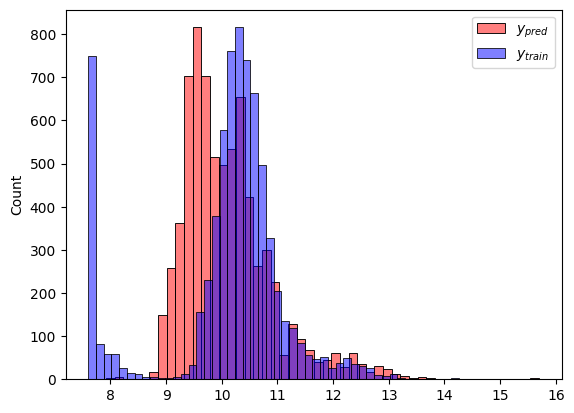

In [226]:
sns.histplot(y_pred, color="red", alpha=0.5, bins=50, label="$y_{pred}$")
sns.histplot(y_train, color="blue", alpha=0.5, bins=50, label="$y_{train}$")
plt.legend()

We can also check a correlation plot between $y_{train}$ and $y_{pred}$:

<Axes: xlabel='$y_{train}$', ylabel='$y_{pred}$'>

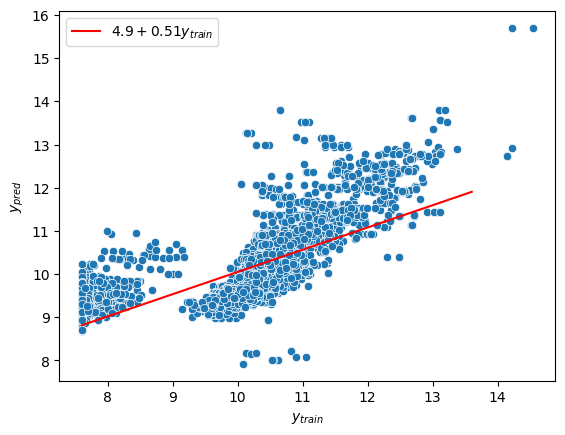

In [227]:
import matplotlib.pyplot as plt

sns.scatterplot(x=y_train, y=y_pred)
plt.xlabel("$y_{train}$")
plt.ylabel("$y_{pred}$")
w = train_linear_regression(y_train, y_pred)
x = np.arange(y_train.min(), y_train.max(), 2)
y = w[0] + w[1]*x
sns.lineplot(x=x, y=y, color="red", label=f"${w[0].round(2)} + {w[1].round(2)} y_{{train}}$")

## 2.9 [Root mean squared error](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/09-rmse.md)

The Root Mean Square Error (RMSE) is one way of evaluating regression models. In the previous lesson we have seen that our baseline model, in which we only used the numeric columns, the predictions are a bit off, however we have no way of quantifying it. RMSE is like a score for how well your model makes predictions.

$$
RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^m{(g(x_{i}) - y_i)^2}}
$$

In [228]:
def rmse(y, y_pred):
    return np.sqrt(((y_pred - y)**2).mean())

In [229]:
rmse(y_train, y_pred)

np.float64(0.7784125377551537)

## 2.10 [Using RMSE on validation data](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/10-car-price-validation.md)

Let's create a function to prepare X:

In [230]:
def prepare_X(df):
    return (
        df[["engine_hp", "city_mpg", "popularity"]]
        .fillna(0)
        .values
    )

We will train the model again:

In [231]:
X_train = prepare_X(df_train)
w = train_linear_regression(X_train, y_train)

Now let's prepare the feature matrix for the validation dataset:

In [232]:
X_val = prepare_X(df_val)

We can use the weights that we found with the training dataset to make predictions using the validation dataset:

In [233]:
y_pred = w[0] + X_val.dot(w[1:])

We calculate the RMSE for the validation dataset predictions:

In [234]:
rmse(y_val, y_pred)

np.float64(0.7795534081084994)

The training dataset predictions had an RMSE of 0.778. The validation dataset has an RMSE of 0.780. Let's transform back $y_{val}$ and $y_{pred}$ and calculate the RMSE in the original values (price).

In [235]:
rmse(np.expm1(y_val), np.expm1(y_pred))

np.float64(55896.394273287806)

The RMSE is a measure for the average prediction error. The value that we found, 55896, means that on average our predictions are off by a price of 55896. Let's calculate the RMSE if we always predicted the mean of the dataset:

In [236]:
rmse(np.expm1(y_val), np.expm1(y_val.mean()))

np.float64(49684.75746258362)

This demonstrates that our linear regression model is not very good as it cannot beat a very naive prediction strategy like always predicting the mean.

## 2.11 [Feature engineering](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/11-feature-engineering.md)

Now let's try to improve our model. In our dataset we have the `Year` feature. We can use this to derive the age of a car. How we'll do this is by taking the newest car in the dataset and setting that to 0 years:

In [237]:
(
    df
    .assign(age=df.year.max() - df.year)
)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,age
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135,6
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650,6
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350,6
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450,6
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120,5
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670,5
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620,5
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920,4


In [238]:
def prepare_X(df):
    return (
        df
        .assign(age=df.year.max() - df.year)[["engine_hp", "city_mpg", "popularity", "age"]]
        .fillna(0)
        .values
    )

In [239]:
X_train = prepare_X(df_train)
w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w[0] + X_val.dot(w[1:])
rmse(y_val, y_pred)

np.float64(0.5248578872896877)

In [240]:
rmse(np.expm1(y_val), np.expm1(y_pred))

np.float64(35245.65156165592)

RMSE went down quite a bit and now it does beat always predicting the mean.

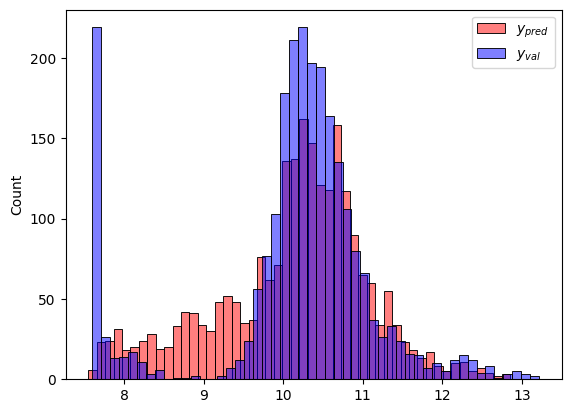

In [241]:
sns.histplot(y_pred, color="red", alpha=0.5, bins=50, label="$y_{pred}$")
sns.histplot(y_val, color="blue", alpha=0.5, bins=50, label="$y_{val}$")
plt.legend()

## 2.12 [Categorical variables](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/12-categorical-variables.md)

Categorical columns can be encoded by creating binary columns for each category.

In [242]:
def prepare_X(df):
    return (
        df
        .assign(age=df.year.max() - df.year)
        .assign(**{f"num_doors_{v}": (df.number_of_doors == v).astype(int) for v in [2, 3, 4]})
        .loc[:, ["engine_hp", "city_mpg", "popularity", "age"] + [f"num_doors_{v}" for v in [2, 3, 4]]]
        .fillna(0)
        .values
    )

In [243]:
X_train = prepare_X(df_train)
w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w[0] + X_val.dot(w[1:])
rmse(y_val, y_pred)

np.float64(0.5242271619109395)

Adding the number of doors did not improve the RMSE score appreciably. Let's now add the column `make`.

In [244]:
df.make.value_counts().head().index

Index(['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'], dtype='object', name='make')

In [245]:
def prepare_X(df):
    return (
        df
        .assign(age=df.year.max() - df.year)
        .assign(**{f"num_doors_{v}": (df.number_of_doors == v).astype(int) for v in [2, 3, 4]})
        .assign(**{f"make_{v}": (df.make == v).astype(int) for v in ["chevrolet", "ford", "volkswagen", "toyota", "dodge"]})
        .loc[:, ["engine_hp", "city_mpg", "popularity", "age"] + [f"num_doors_{v}" for v in [2, 3, 4]] + [f"make_{v}" for v in ["chevrolet", "ford", "volkswagen", "toyota", "dodge"]]]
        .fillna(0)
        .values
    )

In [246]:
X_train = prepare_X(df_train)
w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w[0] + X_val.dot(w[1:])
rmse(y_val, y_pred)

np.float64(0.5189747645026125)

Adding `make` improved the score a bit, but not a very significant improvement.

In [247]:
categorical_variables = ["make", "model", "engine_fuel_type", "transmission_type", "driven_wheels", "market_category", "vehicle_size", "vehicle_style", "number_of_doors"]

categories = {k: df[k].value_counts().head().index.to_list() for k in categorical_variables}

In [248]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'model': ['silverado_1500',
  'tundra',
  'f-150',
  'sierra_1500',
  'beetle_convertible'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback'],
 'number_of_doors': [4.0, 2.0, 3.0]}

In [249]:
def prepare_X(df):
    return (
        df
        .assign(age=df.year.max() - df.year)
        .pipe(lambda df_: df_.assign(**{f"{k}_{vv}": (df_[k] == vv).astype(int) for k, v in categories.items() for vv in v}))
        .pipe(lambda df_: df_.loc[:, ["engine_hp", "city_mpg", "popularity", "age"] + [c for c in df_.columns for k in categories.keys() if k+"_" in c]])
        .fillna(0)
        .values
    )

In [250]:
X_train = prepare_X(df_train)
w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w[0] + X_val.dot(w[1:])
rmse(y_val, y_pred)

np.float64(42.519120218488936)

The RMSE exploded. Also the weights are astronomically high:

In [251]:
w

array([-3.36110132e+16, -2.12374742e-01, -3.00014730e+00, -1.99600067e-03,
       -9.62411591e-01, -5.52311175e+00, -4.73600242e+00,  8.99984695e+00,
        9.95101752e+00, -8.86991027e+00, -4.77506934e+01, -2.41518580e+01,
       -2.15117318e+01, -3.70668761e+01,  1.05808653e+01,  1.04051795e+02,
        1.19546693e+02,  9.87393944e+01,  1.73144812e+02, -6.95972738e+01,
        3.67287172e+16,  3.67287172e+16,  3.67287172e+16,  3.67287172e+16,
        3.67287172e+16, -3.11770402e+15, -3.11770402e+15, -3.11770402e+15,
       -3.11770402e+15, -1.11919316e+00, -8.96822926e-02, -1.17569495e-01,
       -2.41131789e-01, -1.87821102e+00,  3.95138325e+02,  3.93620177e+02,
        3.93187434e+02, -1.16746982e-01, -1.28853538e-02,  1.45169007e-01,
        3.69429664e-01, -1.82290969e-01, -5.64673070e-01, -7.41035161e-01,
       -8.74507451e-01])

We will take care of this with regularization.

## 2.13 [Regularization](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/13-regularization.md)

First, let's understand what has happened. Let's consider the Normal Equation:

$$
\mathbf{w} \approx (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

The first part $(\mathbf{X}^T \mathbf{X})^{-1}$ only exists if the matrix has full rank. This means that $\mathbf{X}^T \mathbf{X}$ must be invertible, which requires that the columns of $\mathbf{X}$ are linearly independent. Let's look at an example where the columns of $\mathbf{X}$ are not linearly independent:

In [252]:
X = np.array([
    [1, 2, 2],
    [2, 2, 2],
    [3, 2, 2],
])

If we try to compute the inverse $(\mathbf{X}^T \mathbf{X})^{-1}$, we get:

In [253]:
np.linalg.inv(X.T.dot(X))

LinAlgError: Singular matrix

Now let's add a very small amount of noise to one of the elements in the last column:

In [254]:
X = np.array([
    [1, 2, 2],
    [2, 2, 2],
    [3, 2, 2],
    [4, 2, 2],
    [5, 2, 2],
    [6, 2, 2.000001],
])

y = np.array([3, 2, 4, 2, 5, 10])

In this case, the matrix technically is no longer rank-deficient or singular. But, it is very close to it. Instead of a singular matrix, we get:

In [255]:
XTX_inv = np.linalg.inv(X.T.dot(X))

In [256]:
XTX_inv.dot(X.T).dot(y)

array([ 3.92588447e-01, -5.64360755e+06,  5.64360857e+06])

We do find a solution, but the weights are huge. Let's consider this $\mathbf{X}^T \mathbf{X}$:

In [257]:
XTX = np.array([
    [1, 2, 2],
    [2, 2, 2.000001],
    [3, 2, 2],
])

np.linalg.inv(XTX)

array([[-5.0000000e-01,  0.0000000e+00,  5.0000000e-01],
       [ 5.0000075e+05, -1.0000000e+06,  4.9999975e+05],
       [-5.0000000e+05,  1.0000000e+06, -5.0000000e+05]])

What we can do, is add a small number to the diagonal of this matrix. This will make reduce the chance that the matrix is singular:

In [258]:
XTX = np.array([
    [1.01, 2, 2],
    [2, 2.01, 2.00001],
    [3, 2, 2.01],
])
np.linalg.inv(XTX)

array([[ -0.67407567,   0.3363651 ,   0.33602874],
       [-33.30064986,  66.76679135, -33.29997545],
       [ 34.14105807, -66.93665572,  33.13028093]])

The weights are getting lower. 

In [259]:
XTX = np.array([
    [1, 2, 2],
    [2, 2, 2.000001],
    [3, 2, 2],
])

XTX = XTX + 0.01 * np.eye(3)  # 0.01 is a hyperparameter, you can choose how much regularization you would like

In [260]:
np.linalg.inv(XTX)

array([[ -0.67397238,   0.33616259,   0.33612897],
       [-33.28014681,  66.72659325, -33.28007941],
       [ 34.12050286, -66.89635536,  33.11033428]])

Regularization is a way of controlling the weights. Let's update our `train_linear_regression` function:

In [261]:
def train_linear_regression(X, y, alpha=0.001):
    X = np.column_stack([np.ones(X.shape[0]), X])
    return np.linalg.inv((X.T.dot(X) + alpha * np.eye(X.shape[1]))).dot(X.T).dot(y)

In [262]:
X_train = prepare_X(df_train)
w = train_linear_regression(X_train, y_train, alpha=1e-9)
X_val = prepare_X(df_val)
y_pred = w[0] + X_val.dot(w[1:])
rmse(y_val, y_pred)

np.float64(0.46663517044032593)

The RMSE is not only better than the unregularized version, it is also better than when we did not include all the features.

## 2.14 [Tuning the model](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/14-tuning-model.md)

Goal in this lesson is to find the best parameters for $r$:

In [263]:
for alpha in [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]:
    w = train_linear_regression(X_train, y_train, alpha=alpha)
    X_val = prepare_X(df_val)
    y_pred = w[0] + X_val.dot(w[1:])
    print(alpha, "\n", w[0], "\n", rmse(y_val, y_pred), "\n")

0 
 -3.3611013156939696e+16 
 42.519120218488936 

1e-05 
 8.108683129742504 
 0.46648555794125474 

0.0001 
 6.410180019671685 
 0.4664856004404916 

0.001 
 6.414991458108526 
 0.4664860216702677 

0.01 
 6.4063030753200465 
 0.46649026592166476 

0.1 
 6.324365720439223 
 0.46653533105636324 

1 
 5.7902755668971455 
 0.46717612701131583 

10 
 4.508532659722132 
 0.48041588740375313 



Without regularization, bias term is huge and rmse as well. With a little bit of regularization, score improves strongly. Towards regularization alpha of 10, it degrades again. We will pick 0.001 for model training:

In [264]:
w = train_linear_regression(X_train, y_train, alpha=0.001)
X_val = prepare_X(df_val)
y_pred = w[0] + X_val.dot(w[1:])
print(rmse(y_val, y_pred))

0.4664860216702677


## 2.15 [Using the model](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/15-using-model.md)

Now we will evaluate the test set.

In [265]:
w = train_linear_regression(X_train, y_train, alpha=alpha)
X_test = prepare_X(df_test)
y_pred = w[0] + X_test.dot(w[1:])
print(rmse(y_test, y_pred))

0.4718281702455486


The score is a bit worse compared to the validation score. Therefore our model generalizes.

In [266]:
X_trainval = prepare_X(pd.concat([df_train, df_val]))
y_trainval = np.concat([y_train, y_val])
w = train_linear_regression(X_trainval, y_trainval, alpha=alpha)
X_test = prepare_X(df_test)
y_pred = w[0] + X_test.dot(w[1:])

print(rmse(y_test, y_pred))

0.46755987408102107


This translates to an average price error of about 40000:

In [267]:
rmse(np.expm1(y_test), np.expm1(y_pred))

np.float64(39652.89560909608)

When we use both training and validation sets to determine $w$, we find a better score than when using the training set alone.

Now, let's use a particular sample and evaluate it:

In [268]:
df_test.iloc[15]

make                                          honda
model                                         s2000
year                                           2008
engine_fuel_type        premium_unleaded_(required)
engine_hp                                     237.0
engine_cylinders                                4.0
transmission_type                            manual
driven_wheels                      rear_wheel_drive
number_of_doors                                 2.0
market_category      factory_tuner,high-performance
vehicle_size                                compact
vehicle_style                           convertible
highway_mpg                                      25
city_mpg                                         18
popularity                                     2202
msrp                                          36300
Name: 15, dtype: object

Usually, we don't get a DataFrame. Rather, a user inputs information in a website form, this is sent as json to our server hosting our ML model, which then makes a prediction and sends json back:

In [269]:
import json


car = df_test.drop(columns='msrp').iloc[15].to_dict()  # This is sent by the user
car

{'make': 'honda',
 'model': 's2000',
 'year': 2008,
 'engine_fuel_type': 'premium_unleaded_(required)',
 'engine_hp': 237.0,
 'engine_cylinders': 4.0,
 'transmission_type': 'manual',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 2.0,
 'market_category': 'factory_tuner,high-performance',
 'vehicle_size': 'compact',
 'vehicle_style': 'convertible',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2202}

Our model turns it into a Dataframe

In [270]:
df_small = pd.DataFrame([car])

In [271]:
X_small = prepare_X(df_small)
X_small

array([[2.370e+02, 1.800e+01, 2.202e+03, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00]])

In [272]:
y_pred = w[0] + X_small.dot(w[1:])

This is the prediction:

In [273]:
y_pred

array([11.02340981])

Let's transform it to price:

In [274]:
np.expm1(y_pred)

array([61291.31909926])

Let's compare it to the real price:

In [275]:
df_test.iloc[20].msrp

np.int64(35000)

It's off by 26000, which is not great. But considering that the average error of the model is close to 40000, it's not unexpected either.

## 2.16 [Car price prediction project summary](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/16-summary.md)

No notes

## 2.17 [Explore more](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/17-explore-more.md)

No notes

## 2.18 [Homework](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/02-regression/homework.md)

[Go to week_2_homework.ipynb](https://github.com/kemaldahha/machine-learning-course/blob/main/week_2_homework.ipynb)